**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("pheatmap")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**File existence**

In [4]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "*XY_*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.tsv 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_cv05fold.rds 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_model.rds 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_model.xgb 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_shap_table.rds 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_shap_value.rds 


### Import data: variant delta

In [6]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY = dat
print(dim(dat))
fun_display_table(dat[1:3, 1:6])

[1] 99981   580


Variant_ID,Delta,AC0014:BATF/FOSL:bZIP,AC0078:CTCF/CTCFL:C2H2_ZF,AC0180:ZSCAN/ZNF:C2H2_ZF,AC0241:NFE2L/JUN:bZIP
chr4:74487586:A:G:C,0.9649841,7.116993,6.693877,1.062241,1.914324
chr9:135685432:G:G:C,0.9454227,7.116993,0.000000,-7.061319,1.914325
chr1:173251490:G:G:C,0.9101272,7.116993,0.000000,0.000000,1.914324


In [7]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "results.xgb.summary.event.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xbg_summary_event = dat
print(dim(dat))
fun_display_table(dat[1:3, 1:6])

[1] 2446456       9


RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled
1,AC0403:DBP/HLF:bZIP,Gain,0.1505788,5.86555,0.8256718
2,AC0403:DBP/HLF:bZIP,Gain,0.1647743,5.86555,0.8256718
3,AC0403:DBP/HLF:bZIP,Gain,0.1223084,5.86555,0.8256718


In [8]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "results.xgb.summary.motif.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xbg_summary_motif = dat
print(dim(dat))
fun_display_table(dat[1:3, 1:6])

[1] 1114   10


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value
AC0403:DBP/HLF:bZIP,Gain,1718,0.9778813,0.0221187,0.0398565
AC0403:DBP/HLF:bZIP,Loss,383,0.0026110,0.9973890,-0.0005409
AC0547:ATF/CREB:bZIP,Gain,2096,0.9990458,0.0009542,0.0108390


## Plot global delta (STARR)

In [9]:
### get the variant and delta (BlueSTARR)
dat = dat_XY
dat = dat %>% dplyr::select(Variant_ID, Delta) %>% dplyr::arrange(desc(Delta))
vec = dat$Variant_ID

### assign and show
dat_Y = dat
vec_txt_variant_sort = vec

print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99981     2


Variant_ID,Delta
chr4:74487586:A:G:C,0.9649841
chr9:135685432:G:G:C,0.9454227
chr1:173251490:G:G:C,0.9101272


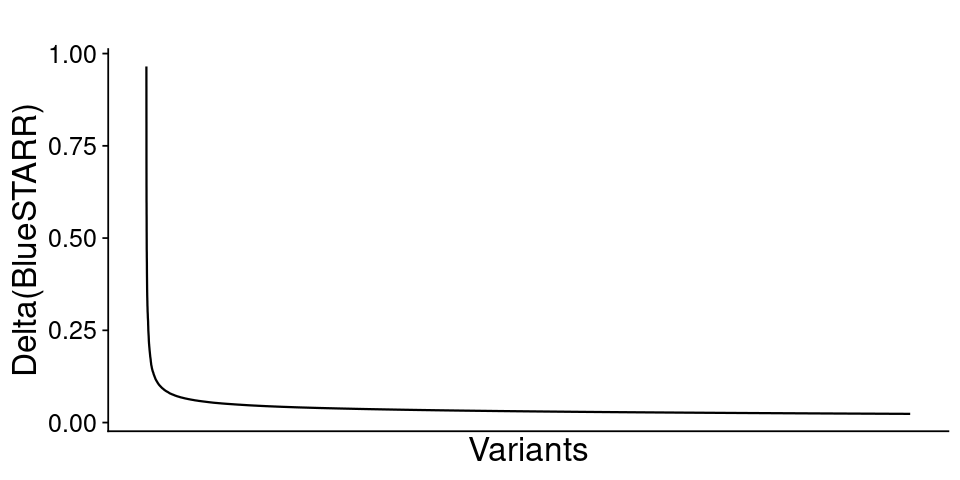

In [10]:
### filter variants
dat = dat_Y

### order variants
dat = dat %>% 
    dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort)) %>%
    dplyr::mutate(Index = as.integer(Variant_ID))
    

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_text(size = 15),
    axis.title   = element_text(size = 20)
)
gpt = ggplot(dat, aes(x=Index, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom +
    labs(x = "Variants", y = "Delta(BlueSTARR)", title = "")

###
gpt_Y_full = gpt
options(repr.plot.height=4, repr.plot.width=8)
print(gpt)

## Plot gain event

In [11]:
dat_motif_gain_activator  = dat_xbg_summary_motif %>% dplyr::filter(Class == "Gain_Activator")
dat_motif_gain_repressor  = dat_xbg_summary_motif %>% dplyr::filter(Class == "Gain_Repressor")
dat_motif_loss_activator  = dat_xbg_summary_motif %>% dplyr::filter(Class == "Loss_Activator")
dat_motif_loss_repressor  = dat_xbg_summary_motif %>% dplyr::filter(Class == "Loss_Repressor")

## Get motif

In [12]:
dat = dat_motif_gain_activator
dat = dat %>% dplyr::arrange(desc(Mean_SHAP_Abs))
vec = dat$Motif

vec_txt_motif_gain_activator = vec
print(dim(dat))
fun_display_table(head(dat, 10))

[1] 34 10


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
AC0403:DBP/HLF:bZIP,Gain,1718,0.9778813,0.0221187,0.0398565,0.0398985,-0.2703651,0.6960863,Gain_Activator
AC0499:ZBTB:C2H2_ZF,Gain,887,0.8872604,0.1127396,0.0151560,0.0151787,0.4265377,0.4105118,Gain_Activator
AC0544:GMEB:SAND,Gain,876,0.8093607,0.1906393,0.0107492,0.0110177,0.6686943,0.5981147,Gain_Activator
AC0014:BATF/FOSL:bZIP,Gain,1582,0.5549937,0.4450063,0.0103926,0.0109819,0.2982700,0.3570869,Gain_Activator
AC0547:ATF/CREB:bZIP,Gain,2096,0.9990458,0.0009542,0.0108390,0.0108395,0.3827125,0.5910318,Gain_Activator
"AC0601:ONECUT/CUX:CUT,Homeodomain",Gain,530,0.8886792,0.1113208,0.0072652,0.0072730,-0.0095170,0.4414508,Gain_Activator
AC0002:PROP/ALX:Homeodomain,Gain,695,0.8402878,0.1597122,0.0059596,0.0062833,0.7126210,0.1795127,Gain_Activator
AC0351:GRHL/TFCP:Grainyhead,Gain,2430,0.9967078,0.0032922,0.0057158,0.0057186,-0.1226590,0.3416757,Gain_Activator
AC0390:CREB/JUND:bZIP,Gain,1907,0.9874148,0.0125852,0.0045360,0.0045786,-0.4038711,0.2954366,Gain_Activator
AC0241:NFE2L/JUN:bZIP,Gain,2411,0.9751141,0.0248859,0.0040638,0.0040654,-0.3751839,0.3367259,Gain_Activator


In [13]:
dat = dat_motif_loss_repressor
dat = dat %>% dplyr::arrange(desc(Mean_SHAP_Abs))
vec = dat$Motif

vec_txt_motif_loss_repressor = vec
print(dim(dat))
fun_display_table(head(dat, 10))

[1] 21 10


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
AC0526:GFI/GFI1B:C2H2_ZF,Loss,1975,0.8956962,0.1043038,0.0035525,0.0036021,-0.7330900,0.1690093,Loss_Repressor
AC0556:USF/BHLHE:bHLH,Loss,1783,1.0000000,0.0000000,0.0028476,0.0028476,-0.7366666,0.3740980,Loss_Repressor
AC0239:BACH/NFE:bZIP,Loss,1760,0.9443182,0.0556818,0.0024467,0.0024547,-0.8035440,0.2158894,Loss_Repressor
AC0276:ZNF:C2H2_ZF,Loss,3301,0.9624356,0.0375644,0.0024176,0.0024501,-0.7994317,0.2974367,Loss_Repressor
AC0076:OVOL:C2H2_ZF,Loss,455,0.9890110,0.0109890,0.0023132,0.0023134,-0.3660846,0.2593174,Loss_Repressor
AC0606:SNAI/ZEB:C2H2_ZF,Loss,5632,0.9994673,0.0005327,0.0020243,0.0020244,0.7041030,0.1929038,Loss_Repressor
AC0194:ZNF:C2H2_ZF,Loss,4830,0.5979296,0.4020704,0.0018231,0.0018914,-0.8372227,0.2626648,Loss_Repressor
AC0555:SREBF:bHLH,Loss,1536,0.9967448,0.0032552,0.0017846,0.0017864,-0.5996551,0.2076240,Loss_Repressor
AC0400:GMEB:SAND,Loss,449,0.9510022,0.0489978,0.0015163,0.0015169,-0.3462493,0.1425764,Loss_Repressor
"AC0566:ZSCAN:C2H2_ZF,MADF",Loss,400,0.7125000,0.2875000,0.0010109,0.0010150,-0.8980080,0.1096501,Loss_Repressor


## Get event

In [14]:
head(dat_xbg_summary_event)

RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,AC0403:DBP/HLF:bZIP,Gain,0.1505788,5.865550,0.8256718,0.001276607,chr4:74487586:A:G:C,0.9649841
2,AC0403:DBP/HLF:bZIP,Gain,0.1647743,5.865550,0.8256718,0.001276607,chr9:135685432:G:G:C,0.9454227
3,AC0403:DBP/HLF:bZIP,Gain,0.1223084,5.865550,0.8256718,0.001276607,chr1:173251490:G:G:C,0.9101272
4,AC0403:DBP/HLF:bZIP,Gain,0.1554775,5.865550,0.8256718,0.001276607,chr1:147523391:G:G:C,0.9088001
5,AC0403:DBP/HLF:bZIP,Gain,0.1920806,3.999299,0.7220523,0.001276607,chr18:54580749:A:G:T,0.8622959
6,AC0403:DBP/HLF:bZIP,Gain,0.1253641,5.865550,0.8256718,0.001276607,chr7:80949454:A:G:C,0.8393378


In [15]:
### Cases for Gain–Activators
dat = dat_xbg_summary_event
dat = dat %>%
    dplyr::filter(
        Event_Type == "Gain",
        Motif %in% vec_txt_motif_gain_activator,
        SHAP_Value > 0
    ) %>%
    dplyr::mutate(Rank_Score = abs(SHAP_Value) * abs(Motif_Delta)) %>%
    dplyr::arrange(desc(Rank_Score))

### assign and show
dat_event_gain_activator = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 43045    10


RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta,Rank_Score
9,AC0544:GMEB:SAND,Gain,0.1156853,19.90262,1,0.0002638,chr2:6818290:C:C:G,0.7633680,2.302442
19,AC0544:GMEB:SAND,Gain,0.1029144,19.90262,1,0.0002638,chr18:57253271:T:C:G,0.5967012,2.048266
2,AC0544:GMEB:SAND,Gain,0.1024493,19.90262,1,0.0002638,chr9:135685432:G:G:C,0.9454227,2.039011


In [16]:
### Loss–Repressors
dat = dat_xbg_summary_event
dat = dat %>%
    dplyr::filter(
        Event_Type == "Loss",
        Motif %in% vec_txt_motif_loss_repressor,
        SHAP_Value > 0
    ) %>%
    dplyr::mutate(Rank_Score = abs(SHAP_Value) * abs(Motif_Delta)) %>%
    dplyr::arrange(desc(Rank_Score))

### assign and show
dat_event_loss_repressor = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 39069    10


RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta,Rank_Score
247,AC0526:GFI/GFI1B:C2H2_ZF,Loss,0.0651424,-13.41296,0.0000001,0.0001438,chr10:129462001:A:A:T,0.2544902,0.8737528
48,AC0276:ZNF:C2H2_ZF,Loss,0.0606435,-10.02180,0.0800237,0.0001946,chr5:141795879:G:G:T,0.4643428,0.6077574
47,AC0276:ZNF:C2H2_ZF,Loss,0.0578050,-10.02180,0.0800237,0.0001946,chr18:57341123:G:G:T,0.4661912,0.5793103


## Get variant

In [17]:
# Gain–activators: top variants by strongest Rank_Score
dat = dat_event_gain_activator %>%
  dplyr::group_by(Variant_ID) %>%
  dplyr::summarise(Max_Rank = max(Rank_Score), .groups = "drop") %>%
  dplyr::arrange(desc(Max_Rank))

vec_txt_variant_gain_activator = head(dat$Variant_ID, 100)

# Loss–repressors: top variants by strongest Rank_Score
dat = dat_event_loss_repressor %>%
  dplyr::group_by(Variant_ID) %>%
  dplyr::summarise(Max_Rank = max(Rank_Score), .groups = "drop") %>%
  dplyr::arrange(desc(Max_Rank))

vec_txt_variant_loss_repressor = head(dat$Variant_ID, 100)

## Summarize gain/loss events for plot

In [18]:
### Heatmap data for Gain–Activators
dat_event_gain_plot = dat_event_gain_activator %>%
  dplyr::filter(
      Variant_ID %in% vec_txt_variant_gain_activator,
      Motif      %in% vec_txt_motif_gain_activator
  ) %>%
  dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels = vec_txt_variant_sort),
    Motif      = factor(Motif,      levels = rev(vec_txt_motif_gain_activator))
  )

head(dat_event_gain_plot)

RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta,Rank_Score
<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
9,AC0544:GMEB:SAND,Gain,0.11568534,19.90262,1,0.0002637909,chr2:6818290:C:C:G,0.7633680,2.302442
19,AC0544:GMEB:SAND,Gain,0.10291438,19.90262,1,0.0002637909,chr18:57253271:T:C:G,0.5967012,2.048266
2,AC0544:GMEB:SAND,Gain,0.10244934,19.90262,1,0.0002637909,chr9:135685432:G:G:C,0.9454227,2.039011
4,AC0544:GMEB:SAND,Gain,0.09671219,19.90262,1,0.0002637909,chr1:147523391:G:G:C,0.9088001,1.924826
22,AC0544:GMEB:SAND,Gain,0.09061071,19.90262,1,0.0002637909,chr5:11925775:G:G:C,0.5948517,1.803391
1,AC0544:GMEB:SAND,Gain,0.08841091,19.90262,1,0.0002637909,chr4:74487586:A:G:C,0.9649841,1.759609


In [19]:
vec = vec_txt_motif_gain_activator
names(vec) = vec
vec = sub("^AC[0-9]+:", "", vec)
vec_txt_motif_gain_plot = vec
print(vec)

              AC0403:DBP/HLF:bZIP               AC0499:ZBTB:C2H2_ZF 
                   "DBP/HLF:bZIP"                    "ZBTB:C2H2_ZF" 
                 AC0544:GMEB:SAND             AC0014:BATF/FOSL:bZIP 
                      "GMEB:SAND"                  "BATF/FOSL:bZIP" 
             AC0547:ATF/CREB:bZIP AC0601:ONECUT/CUX:CUT,Homeodomain 
                  "ATF/CREB:bZIP"      "ONECUT/CUX:CUT,Homeodomain" 
      AC0002:PROP/ALX:Homeodomain       AC0351:GRHL/TFCP:Grainyhead 
           "PROP/ALX:Homeodomain"            "GRHL/TFCP:Grainyhead" 
            AC0390:CREB/JUND:bZIP             AC0241:NFE2L/JUN:bZIP 
                 "CREB/JUND:bZIP"                  "NFE2L/JUN:bZIP" 
             AC0391:FOXN:Forkhead                AC0202:ZNF:C2H2_ZF 
                  "FOXN:Forkhead"                     "ZNF:C2H2_ZF" 
               AC0151:ZNF:C2H2_ZF           AC0402:CEBPB/CEBPE:bZIP 
                    "ZNF:C2H2_ZF"                "CEBPB/CEBPE:bZIP" 
                   AC0331:YBX:CSD 

In [20]:
### Heatmap data for loss
dat_event_loss_plot = dat_event_loss_repressor %>%
  dplyr::filter(
      Variant_ID %in% vec_txt_variant_loss_repressor,
      Motif      %in% vec_txt_motif_loss_repressor
  ) %>%
  dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels = vec_txt_variant_sort),
    Motif      = factor(Motif,      levels = rev(vec_txt_motif_loss_repressor))
  )

head(dat_event_loss_plot)

RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta,Rank_Score
<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
247,AC0526:GFI/GFI1B:C2H2_ZF,Loss,0.06514243,-13.41296,1.422019e-07,0.0001437730,chr10:129462001:A:A:T,0.2544902,0.8737528
48,AC0276:ZNF:C2H2_ZF,Loss,0.06064352,-10.02180,8.002369e-02,0.0001946042,chr5:141795879:G:G:T,0.4643428,0.6077574
47,AC0276:ZNF:C2H2_ZF,Loss,0.05780500,-10.02180,8.002369e-02,0.0001946042,chr18:57341123:G:G:T,0.4661912,0.5793103
5,AC0276:ZNF:C2H2_ZF,Loss,0.05322590,-10.02180,8.002373e-02,0.0001946042,chr18:54580749:A:G:T,0.8622959,0.5334194
1076,AC0526:GFI/GFI1B:C2H2_ZF,Loss,0.03742111,-13.41296,1.066514e-07,0.0001437730,chr6:27917621:A:A:T,0.1244743,0.5019280
639,AC0526:GFI/GFI1B:C2H2_ZF,Loss,0.03706607,-13.41296,1.066514e-07,0.0001437730,chr8:20064536:T:T:A,0.1560580,0.4971658


In [21]:
vec = vec_txt_motif_loss_repressor
names(vec) = vec
vec = sub("^AC[0-9]+:", "", vec)
vec_txt_motif_loss_plot = vec
print(vec)

                    AC0526:GFI/GFI1B:C2H2_ZF 
                         "GFI/GFI1B:C2H2_ZF" 
                       AC0556:USF/BHLHE:bHLH 
                            "USF/BHLHE:bHLH" 
                        AC0239:BACH/NFE:bZIP 
                             "BACH/NFE:bZIP" 
                          AC0276:ZNF:C2H2_ZF 
                               "ZNF:C2H2_ZF" 
                         AC0076:OVOL:C2H2_ZF 
                              "OVOL:C2H2_ZF" 
                     AC0606:SNAI/ZEB:C2H2_ZF 
                          "SNAI/ZEB:C2H2_ZF" 
                          AC0194:ZNF:C2H2_ZF 
                               "ZNF:C2H2_ZF" 
                           AC0555:SREBF:bHLH 
                                "SREBF:bHLH" 
                            AC0400:GMEB:SAND 
                                 "GMEB:SAND" 
                   AC0566:ZSCAN:C2H2_ZF,MADF 
                        "ZSCAN:C2H2_ZF,MADF" 
                       AC0611:NHLH/TFAP:bHLH 
                            "NHLH/

## Plog gain

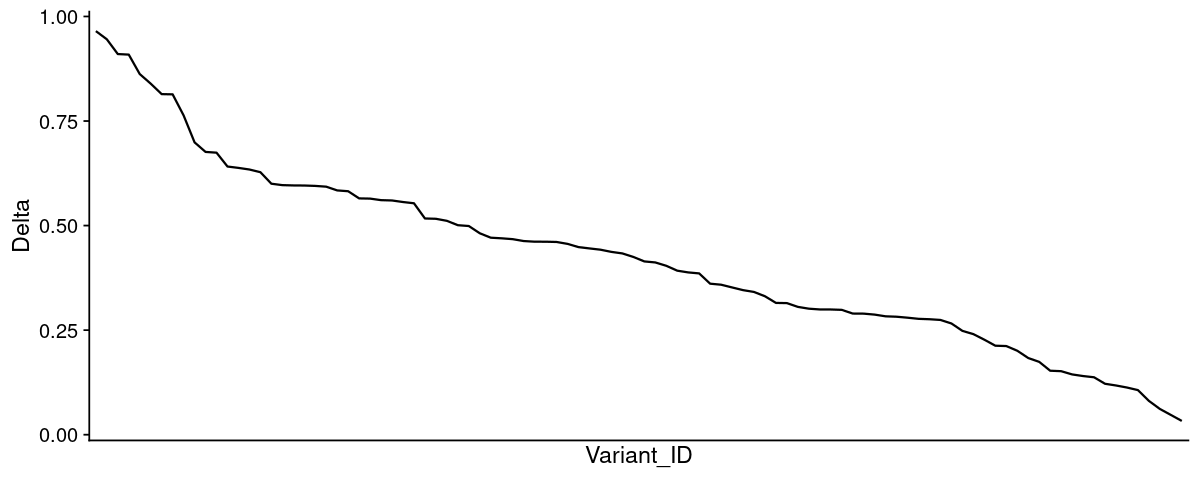

In [22]:
### filter variants
dat = dat_Y
vec = vec_txt_variant_gain_activator

dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

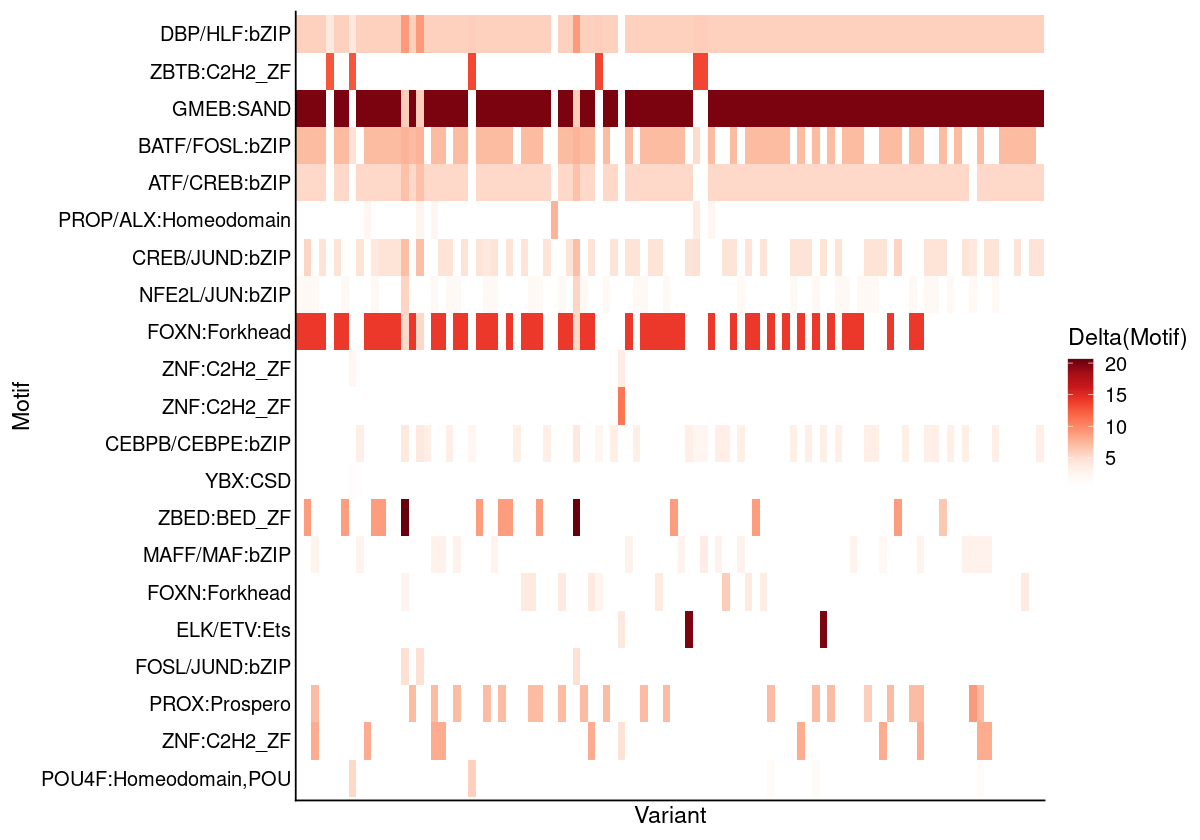

In [23]:
###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
dat = dat_event_gain_plot
vec = vec_txt_motif_gain_plot

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Motif_Delta)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color, name = "Delta(Motif)") +
    scale_y_discrete(labels = vec) +
    labs(x = "Variant", y = "Motif")

gpt_X = gpt
options(repr.plot.height=7, repr.plot.width=10)
print(gpt)

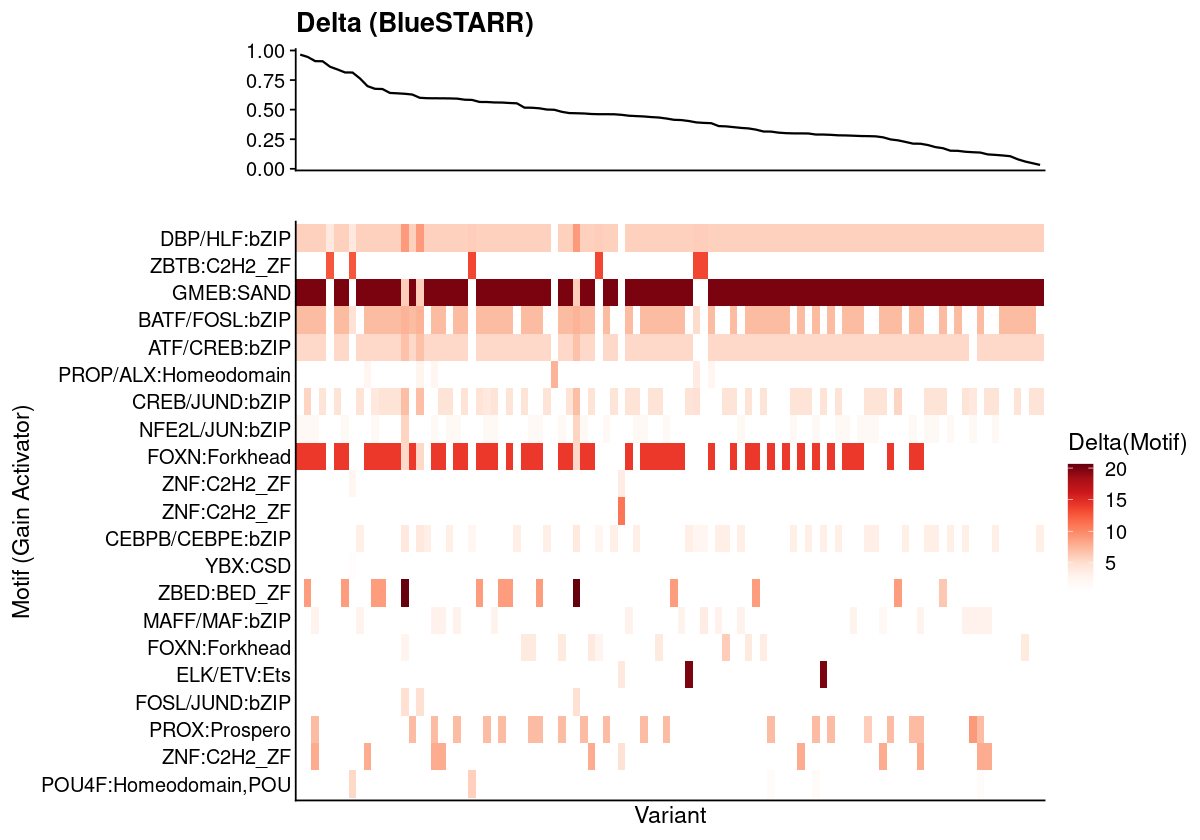

In [24]:
lst = list(
    gpt_Y + labs(x="",        y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="Variant", y = "Motif (Gain Activator)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 3),
    align = "v"
)

plt_XY_gain = plt
options(repr.plot.height=7, repr.plot.width=10)
print(plt)

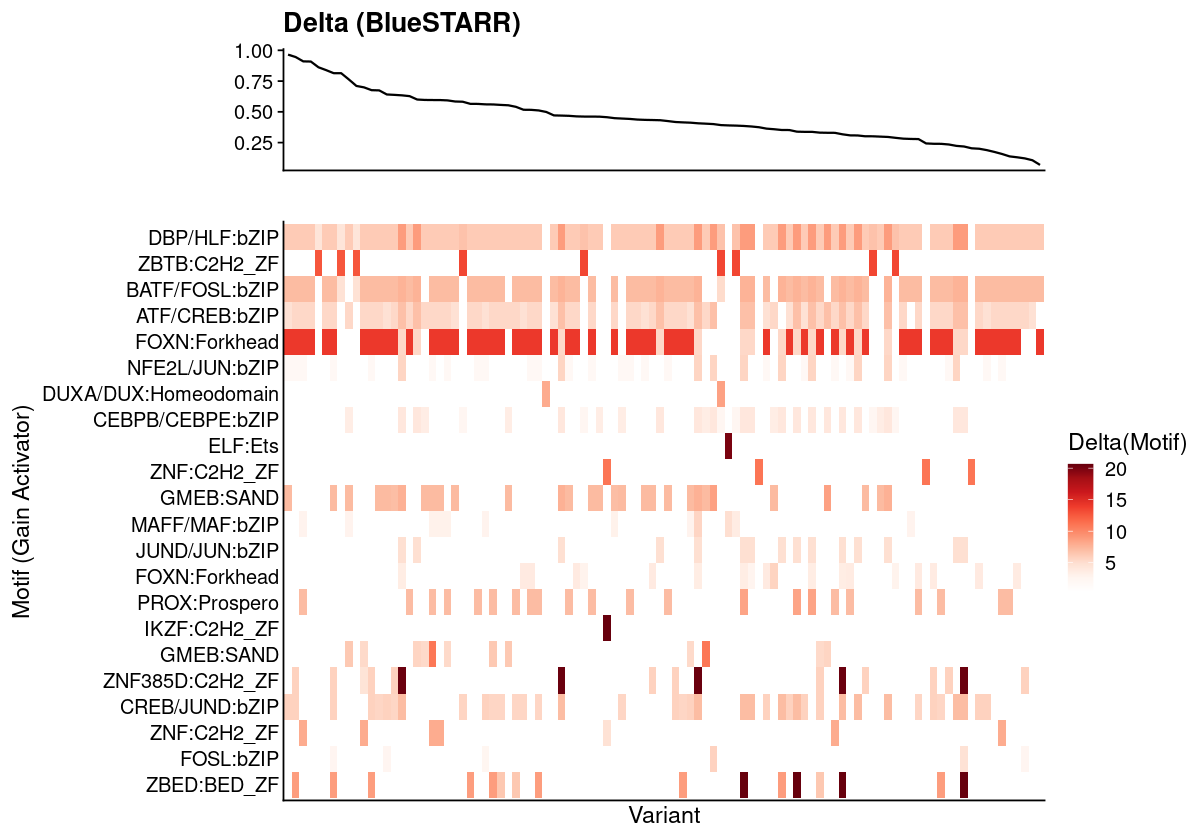

In [127]:
lst = list(
    gpt_Y + labs(x="",        y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="Variant", y = "Motif (Gain Activator)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 3),
    align = "v"
)

plt_XY_gain = plt
options(repr.plot.height=7, repr.plot.width=10)
print(plt)

## Plot loss

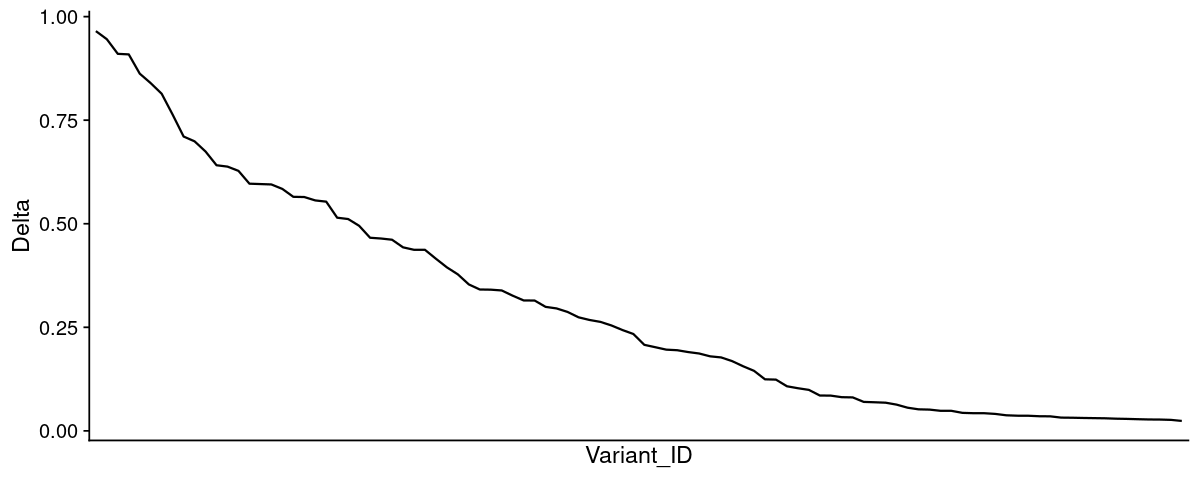

In [25]:
### filter variants
dat = dat_Y
vec = vec_txt_variant_loss_repressor

dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

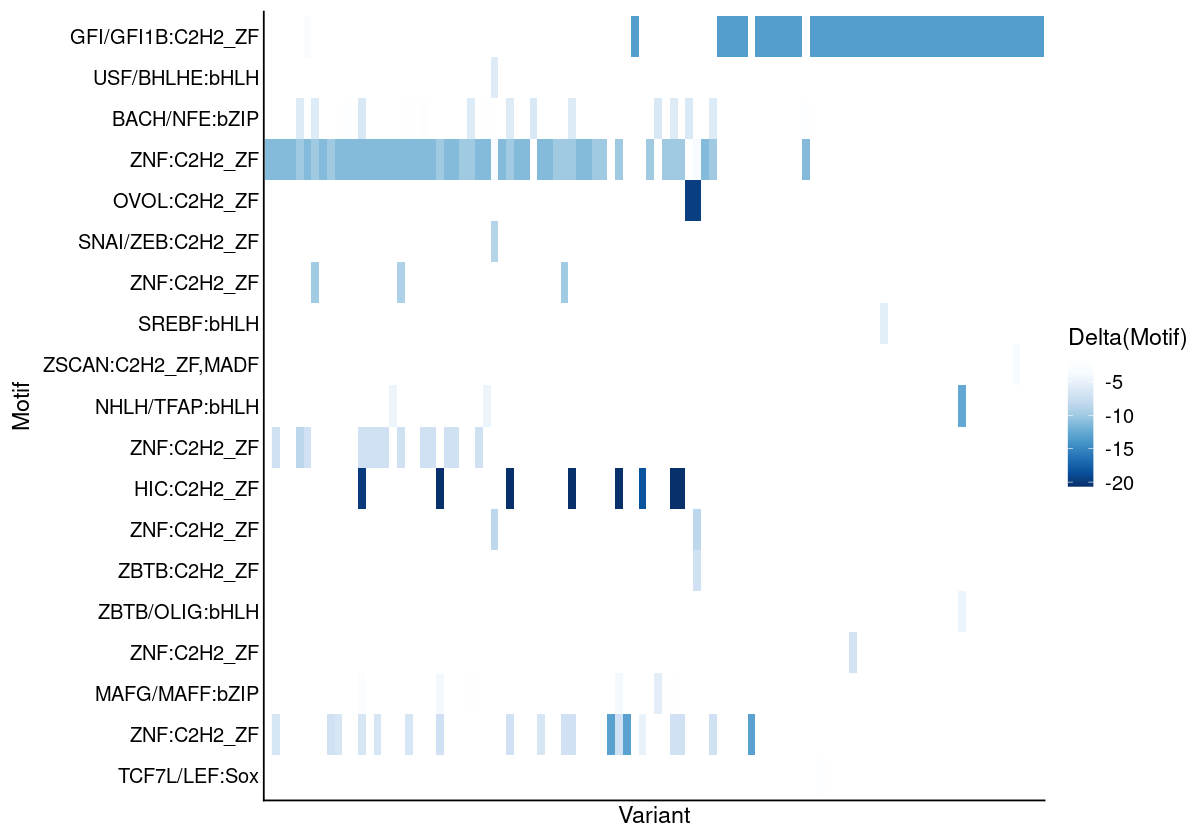

In [26]:
###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
dat = dat_event_loss_plot
vec = vec_txt_motif_loss_plot

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Motif_Delta)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color, name = "Delta(Motif)") +
    scale_y_discrete(labels = vec) +
    labs(x = "Variant", y = "Motif")

gpt_X = gpt
options(repr.plot.height=7, repr.plot.width=10)
print(gpt)

In [27]:
unique(dat$Motif)

[1] AC0526:GFI/GFI1B:C2H2_ZF  AC0276:ZNF:C2H2_ZF       
 [3] AC0068:HIC:C2H2_ZF        AC0239:BACH/NFE:bZIP     
 [5] AC0322:ZNF:C2H2_ZF        AC0194:ZNF:C2H2_ZF       
 [7] AC0216:ZNF:C2H2_ZF        AC0076:OVOL:C2H2_ZF      
 [9] AC0611:NHLH/TFAP:bHLH     AC0556:USF/BHLHE:bHLH    
[11] AC0606:SNAI/ZEB:C2H2_ZF   AC0023:ZNF:C2H2_ZF       
[13] AC0198:ZBTB:C2H2_ZF       AC0244:MAFG/MAFF:bZIP    
[15] AC0555:SREBF:bHLH         AC0609:ZBTB/OLIG:bHLH    
[17] AC0566:ZSCAN:C2H2_ZF,MADF AC0302:ZNF:C2H2_ZF       
[19] AC0430:TCF7L/LEF:Sox     
21 Levels: AC0430:TCF7L/LEF:Sox AC0216:ZNF:C2H2_ZF ... AC0526:GFI/GFI1B:C2H2_ZF

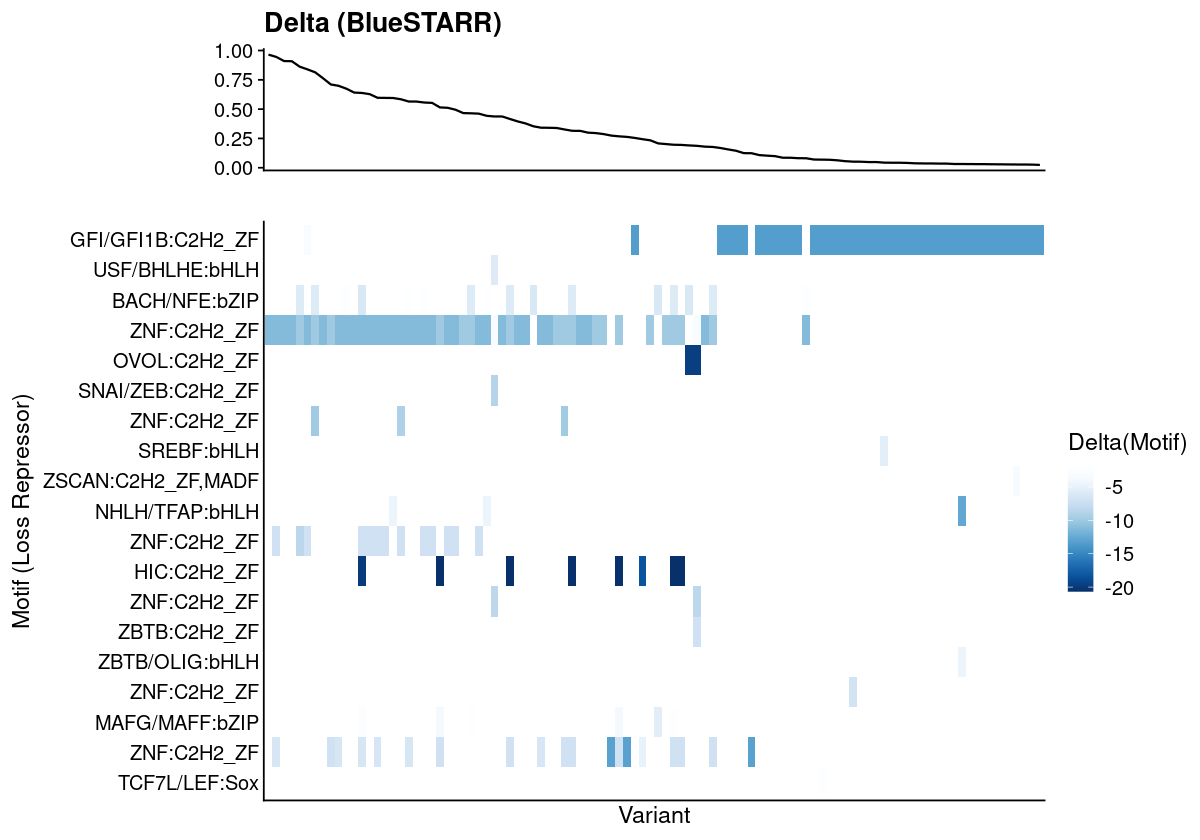

In [28]:
lst = list(
    gpt_Y + labs(x="",        y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="Variant", y = "Motif (Loss Repressor)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 3),
    align = "v"
)

plt_XY_loss = plt
options(repr.plot.height=7, repr.plot.width=10)
print(plt)

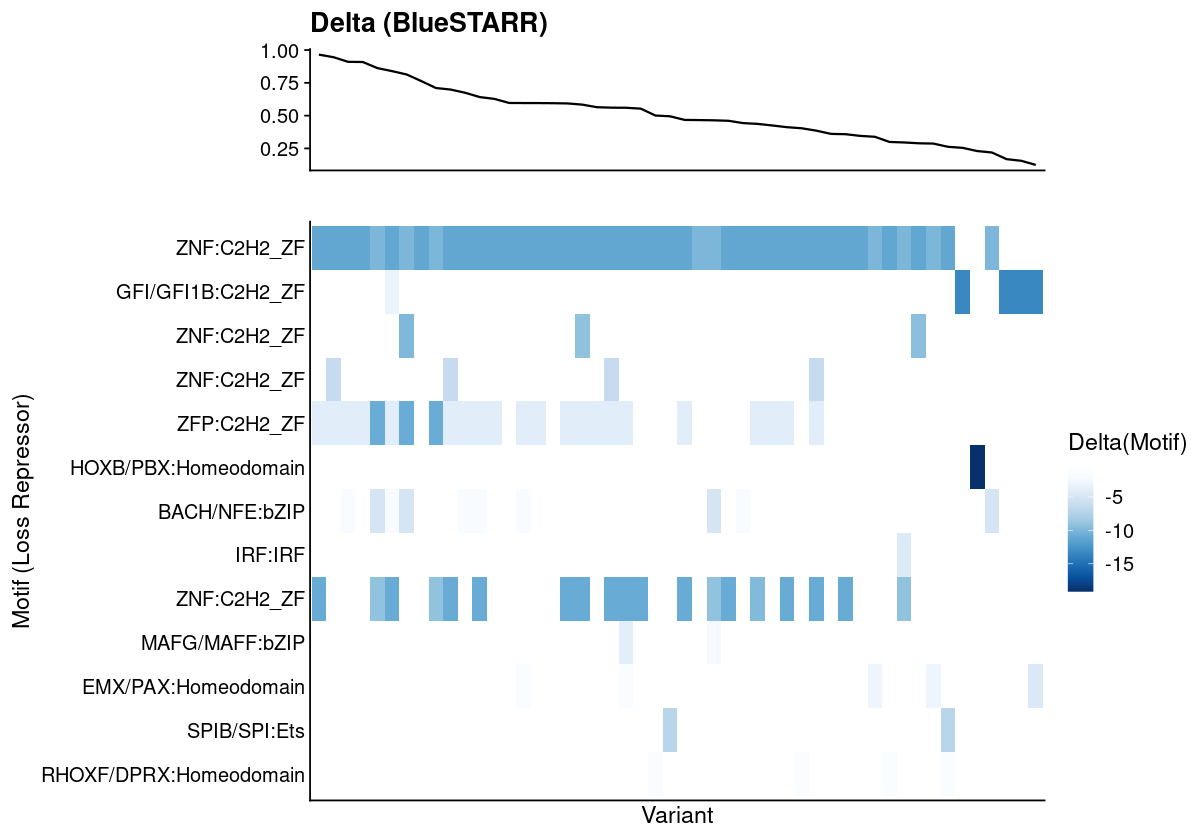

In [119]:
lst = list(
    gpt_Y + labs(x="",        y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="Variant", y = "Motif (Loss Repressor)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 3),
    align = "v"
)

plt_XY_loss = plt
options(repr.plot.height=7, repr.plot.width=10)
print(plt)

## Save figures

In [109]:
plt_export = plt_XY_gain
txt_export = "fig.variant_motif.gain_event.heatmap.subset"
num_height = 7
num_width  = 10

txt_fdiry = "./"
txt_fname = paste(txt_export, "png", sep = ".")
txt_fpath = file.path(txt_fdiry, txt_fname)
ggsave(txt_fpath, plt_export, height = num_height, width = num_width, units = "in")

txt_fdiry = "./"
txt_fname = paste(txt_export, "svg", sep = ".")
txt_fpath = file.path(txt_fdiry, txt_fname)
ggsave(txt_fpath, plt_export, height = num_height, width = num_width, units = "in")

In [110]:
plt_export = plt_XY_loss
txt_export = "fig.variant_motif.loss_event.heatmap.subset"
num_height = 7
num_width  = 10

txt_fdiry = "./"
txt_fname = paste(txt_export, "png", sep = ".")
txt_fpath = file.path(txt_fdiry, txt_fname)
ggsave(txt_fpath, plt_export, height = num_height, width = num_width, units = "in")

txt_fdiry = "./"
txt_fname = paste(txt_export, "svg", sep = ".")
txt_fpath = file.path(txt_fdiry, txt_fname)
ggsave(txt_fpath, plt_export, height = num_height, width = num_width, units = "in")